In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = 'https://www.openml.org/data/get_csv/1595261/phpMawTba'


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Income_logistic_Regression /phpMawTba.csv')

In [ ]:
import os
os.listdir('/content/drive/MyDrive/Income_logistic_Regression ')

['phpMawTba.csv', ' Income_logistics.ipynb']

# Problem Statement - To predict the person salary can be over 50k or not.


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# Cleaning the data


In [ ]:
df.drop('fnlwgt',axis=1,inplace=True)

In [ ]:
df

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      48842 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  48842 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


In [ ]:
df['class'].value_counts()

,count
class,
<=50K,37155
>50K,11687


In [ ]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(48842, 14)

In [ ]:
df['workclass']=df['workclass'].str.strip()

In [ ]:
 df['workclass']=df['workclass'].replace({'?':np.nan})

In [ ]:
(df == ' ?').sum()

,0
age,0
workclass,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0
capital-gain,0


In [ ]:
 df=df.replace({' ?':np.nan})

In [ ]:
df.isnull().sum()

,0
age,0
workclass,2799
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0
capital-gain,0


In [ ]:
df.shape

(48842, 14)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(45222, 14)

In [ ]:
df['class']=df['class'].str.strip()

In [ ]:
df['class']=df['class'].replace({'0':0})

In [ ]:
df['class'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
df

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df['income']=df['class'].apply(lambda x: 1 if x=='>50K' else 0)

In [ ]:
df['income'].value_counts()

,count
income,
0,34014
1,11208


In [ ]:
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0


In [ ]:
df['education-num'].describe()

,education-num
count,45222.000000
mean,10.118460
std,2.552881
min,1.000000
25%,9.000000
50%,10.000000
75%,13.000000
max,16.000000


In [ ]:
df['education'].dtype

dtype('O')

In [ ]:
df.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0


# Feature Engineering


In [ ]:
 categorical_cols=[ 'workclass', 'marital-status',
       'occupation', 'relationship', 'race', 'sex',  'native-country']

In [ ]:
df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [ ]:
df_encoded.info(

)

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 83 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   age                                         45222 non-null  int64 
 1   education                                   45222 non-null  object
 2   education-num                               45222 non-null  int64 
 3   capital-gain                                45222 non-null  int64 
 4   capital-loss                                45222 non-null  int64 
 5   hours-per-week                              45222 non-null  int64 
 6   class                                       45222 non-null  object
 7   income                                      45222 non-null  int64 
 8   workclass_Local-gov                         45222 non-null  bool  
 9   workclass_Private                           45222 non-null  bool  
 10  workclass_Self-emp-inc     

In [ ]:
df_encoded.drop('education',axis=1,inplace=True)

In [ ]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
for col in bool_cols:
  df_encoded[col]=df_encoded[col].astype(int)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 82 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   age                                         45222 non-null  int64 
 1   education-num                               45222 non-null  int64 
 2   capital-gain                                45222 non-null  int64 
 3   capital-loss                                45222 non-null  int64 
 4   hours-per-week                              45222 non-null  int64 
 5   class                                       45222 non-null  object
 6   income                                      45222 non-null  int64 
 7   workclass_Local-gov                         45222 non-null  int64 
 8   workclass_Private                           45222 non-null  int64 
 9   workclass_Self-emp-inc                      45222 non-null  int64 
 10  workclass_Self-emp-not-inc 

In [ ]:
df_encoded.drop('class',axis=1,inplace=True)

In [ ]:
 df_encoded.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38,9,0,0,50,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,28,12,0,0,40,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,44,10,7688,0,40,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
5,34,6,0,0,30,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
x = df_encoded.drop(columns=['income'])
y = df_encoded['income']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sclr = StandardScaler()

In [ ]:
 numerical_cols = ['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week']

In [ ]:
x_train[numerical_cols]=sclr.fit_transform(x_train[numerical_cols])

In [ ]:
x_test[numerical_cols]=sclr.transform(x_test[numerical_cols])

# Model Training


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
ml = LogisticRegression()


In [ ]:
ml.fit(x_train[['education-num']],y_train)

LogisticRegression()

In [ ]:
y_pred = ml.predict(x_test[['education-num']])

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, roc_auc_score, classification_report,precision_score

#Model Evaluation

In [ ]:
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix \n',cm)

cr = classification_report(y_test,y_pred)
print('classification report \n',cr)

ac = accuracy_score(y_test,y_pred)
print('Accuracy\n',ac)

re = recall_score(y_test,y_pred)
print('Recall Score\n',re)

f1 = f1_score(y_test,y_pred)
print('f1_score\n',f1)

pre = precision_score(y_test,y_pred)
print("Precision score \n",pre)

roc_auc = roc_auc_score(y_test,y_pred)
print('roc_auc_score\n',roc_auc)

confusion matrix 
 [[6524  279]
 [1797  445]]
classification report 
               precision    recall  f1-score   support

           0       0.78      0.96      0.86      6803
           1       0.61      0.20      0.30      2242

    accuracy                           0.77      9045
   macro avg       0.70      0.58      0.58      9045
weighted avg       0.74      0.77      0.72      9045

Accuracy
 0.7704809286898839
Recall Score
 0.19848349687778769
f1_score
 0.3000674308833446
Precision score 
 0.6146408839779005
roc_auc_score
 0.5787360891709239


In [ ]:
from sklearn.metrics import precision_recall_curve,roc_curve

In [ ]:
precision_vals, recall_vals,_ = precision_recall_curve(y_test,y_pred)
print('precision_recall',list(zip(precision_vals,recall_vals)))

precision_recall [(np.float64(0.2478717523493643), np.float64(1.0)), (np.float64(0.6146408839779005), np.float64(0.19848349687778769)), (np.float64(1.0), np.float64(0.0))]


In [ ]:
fpr,tpr,_ = roc_curve(y_test,y_pred)

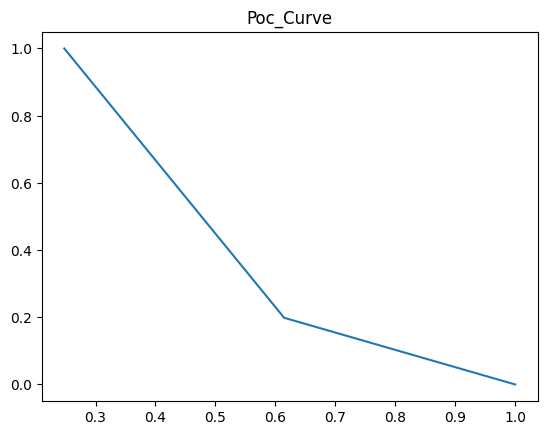

In [ ]:
plt.plot(precision_vals, recall_vals)
plt.title('Poc_Curve')
plt.show()

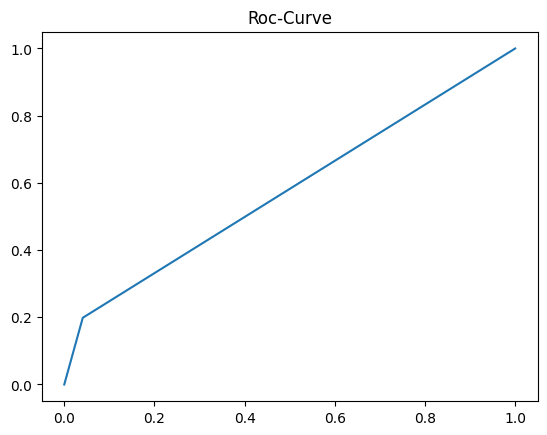

In [ ]:
plt.plot(fpr,tpr)
plt.title('Roc-Curve')
plt.show()